In [21]:
from pycromanager import Core, Studio
import time
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import bh_spc
from bh_spc import spcm
import pprint
from collections import OrderedDict
import datetime

In [22]:
core = Core()
studio = Studio()



In [23]:
roi = core.get_roi()
roi.x,roi.y, roi.width, roi.height

(0, 0, 256, 256)

In [24]:
print(
    f"""
PMT Signal Switch     : {core.get_property("PMTSignalSwitch", "Label")}
Fermat Spiral Scan    : {core.get_property("OSc-LSM", "Dev1-Fermat Spiral Scan")}
Channel 0 Enabled     : {core.get_property("OSc-LSM", "Dev1-EnableChannel0")}
Channel 1 Enabled     : {core.get_property("OSc-LSM", "Dev1-EnableChannel1")}
""".strip()
)

PMT Signal Switch     : TCSPC PreAmp
Fermat Spiral Scan    : No
Channel 0 Enabled     : No
Channel 1 Enabled     : Yes


In [25]:
core.is_sequence_running()

False

In [ ]:
def get_microtimes_MT(duration=0.1, buf_size=32768, mod_no=0):
    spcm.start_measurement(mod_no)
    start = time.monotonic()
    chunks = []

    while True:
        elapsed = time.monotonic() - start
        if elapsed >= duration:
            break

        # progress (updates same line)
        print(f"\rAcquiring: {elapsed:0.2f}/{duration:.2f} s", end="", flush=True)

        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if len(buf):
            chunks.append(buf)
        if len(buf) < buf_size:
            time.sleep(0.001)

    spcm.stop_measurement(mod_no)
    print()  # move to new line after loop

    # drain remaining data
    while True:
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if not len(buf):
            break
        chunks.append(buf)

    if not chunks:
        return np.array([], dtype=np.uint32), np.array([], dtype=np.uint32)

    records = np.concatenate(chunks).view(np.uint32)

    had_gap = np.any(records & (1 << 29))
    print(f"There was {'a' if had_gap else 'no'} gap")

    photons = records[(records & (0b1001 << 28)) == 0]

    max_12bit = 0xFFF
    microtimes = max_12bit - ((photons >> 16) & max_12bit)

    return microtimes, photons

def get_microtimes_MTO(duration = 0.1, buf_size = 32768, mod_no=0):

    spcm.start_measurement(mod_no)
    start_time = time.monotonic()

    data = []  # Collect arrays of data into a list.
    while True:
        elapsed = time.monotonic() - start_time
        if elapsed >= duration:
            spcm.stop_measurement(mod_no)
            break
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if len(buf):
            data.append(buf)
        if len(buf) < buf_size:  # We've read all there is to read.
            time.sleep(0.001)

    # Make sure to read the data that arrived after stopping (if you need it).
    while True:
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if not len(buf):
            break
        data.append(buf)

    records = np.concatenate(data).view(np.uint32)
    len(records)

    had_gap = np.any(np.bitwise_and(records, 1 << 29))
    print("There was {} gap".format("a" if had_gap else "no"))

    photons = np.extract(np.bitwise_and(records, 0b1001 << 28) == 0, records)
    len(photons)

    max_12bit = (1 << 12) - 1  # 4095
    microtimes = np.bitwise_and(np.right_shift(photons, 16), max_12bit)

    # Reverse the microtimes by subtracting from the max value, because the raw
    # microtime is measured from photon to SYNC, not SYNC to photon.
    microtimes = max_12bit - microtimes
    
    return microtimes,photons


In [27]:
## INIT FAST-TIMING DEVICE
spcm.init(r'.\spcm_SLIM.ini')
MODULE_NUMBER = 0 # SPC 180NX
spcm.get_init_status(MODULE_NUMBER)

## SET FAST-TIMING EXPT DURATION
scan_duration = 5 # sec
params = spcm.get_parameters(MODULE_NUMBER)
params.collect_time = scan_duration # sec
spcm.set_parameters(0, params)


In [28]:
params

<Data(cfd_limit_low=-29.41176414489746, cfd_limit_high=80.0, cfd_zc_level=12.850393295288086, cfd_holdoff=5.0, sync_zc_level=0.0, sync_freq_div=1, sync_holdoff=4.0, sync_threshold=-9.803921699523926, tac_range=50.033573150634766, tac_gain=4, tac_offset=3.1372549533843994, tac_limit_low=0.0, tac_limit_high=100.0, adc_resolution=12, ext_latch_delay=0, collect_time=5.0, display_time=1.0, repeat_time=5.0, stop_on_time=1, stop_on_ovfl=0, dither_range=128, count_incr=1, mem_bank=0, dead_time_comp=0, scan_control=0, routing_mode=0, tac_enable_hold=0.0, mode=5, scan_size_x=1, scan_size_y=1, scan_rout_x=1, scan_rout_y=1, scan_polarity=7, scan_flyback=65537, scan_borders=0, pixel_time=4.999999873689376e-06, pixel_clock=0, line_compression=1, trigger=0, ext_pixclk_div=1, rate_count_time=1.0, macro_time_clk=0, add_select=0, adc_zoom=0, xy_gain=1, img_size_x=1, img_size_y=1, img_rout_x=1, img_rout_y=1, master_clock=2, adc_sample_delay=0, detector_type=1, tdc_control=0, chan_enable=16777215, chan_sl

In [29]:
spcm.get_module_info(MODULE_NUMBER)

<ModInfo(module_type=<ModuleType.SPC_180NX: 181>, bus_number=23, slot_number=0, in_use=<InUseStatus.IN_USE_HERE: 1>, init=<InitStatus.OK: 0>)>

In [41]:
## SANITY CHECK IF ROI IS OFF and ROI are square
IMAGE_RES = int(core.get_property('OSc-LSM','LSM-Resolution'))
current_roi = core.get_roi()
W,H =current_roi.width, current_roi.height
if W == H == IMAGE_RES:
    pass

5.0 32768
There was no gap
525456 525456


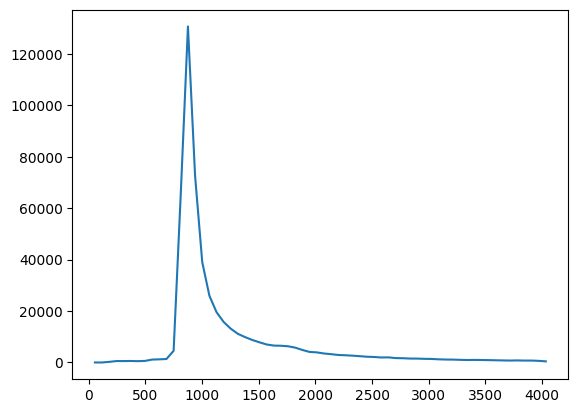

In [54]:

## SANITY CHECK
duration = spcm.get_parameter(MODULE_NUMBER,spcm.ParID.COLLECT_TIME)  # s
buf_size = 2**15  # Max number of 16-bit words in a single read.
print(duration, buf_size)

## PARTICLE SIZE
object_size = 50 #pixels


## MAKE SURE WE ARE ON Ch2 only 
core.set_property("OSc-LSM","Dev1-EnableChannel1","Yes")
core.set_property("OSc-LSM","Dev1-EnableChannel0","No")

## MAKE SURE WE ARE ON TCSPC and SPIRAL
core.set_property("PMTSignalSwitch","Label",'TCSPC PreAmp')
core.set_property("OSc-LSM","Dev1-Fermat Spiral Scan","Yes")
core.set_roi(W-object_size, H-object_size, object_size,object_size)

## STOP RUNNING ACQ
if core.is_sequence_running(): core.stop_sequence_acquisition()

#studio.live().set_live_mode_on(True)
core.start_continuous_sequence_acquisition(0)
mt,ph = get_microtimes_MTO(duration,buf_size,MODULE_NUMBER)
print(len(mt),len(ph))
x,h = np.histogram(mt,64)
plt.plot(h[:-1],x)

#studio.live().set_live_mode_on(False)
core.stop_sequence_acquisition()
core.set_property("OSc-LSM","Dev1-Fermat Spiral Scan","No")
core.set_roi(0,0,W,H)

In [45]:
#core.start_continuous_sequence_acquisition()

In [51]:
spcm.read_rates(0)

<RateValues(sync_rate=80103424.0, cfd_rate=15168.0, tac_rate=14992.0, adc_rate=14784.0)>

In [52]:
spcm.read_rates(0)

<RateValues(sync_rate=80103424.0, cfd_rate=3344.0, tac_rate=3328.0, adc_rate=3264.0)>

In [15]:
core.is_sequence_running()

False

In [16]:
studio.is_program_running()

True

In [20]:
L.get_is_live_mode_on()

False

In [17]:
L = studio.live()

In [18]:
dir(L)

['__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_access_field',
 '_bridge',
 '_close',
 '_close_lock',
 '_closed',
 '_convert_camel_case',
 '_creation_port',
 '_creation_thread',
 '_debug',
 '_deserialize',
 '_hash_code',
 '_interfaces',
 '_ip_address',
 '_iterate',
 '_java_class',
 '_send_and_receive',
 '_set_field',
 '_timeout',
 '_translate_call',
 'access$000',
 'access$002',
 'access$100',
 'access$200',
 'access$300',
 'access$400',
 'access$500',
 'access$600',
 'can_close_viewer',
 'clone',
 'compute_grab_delay_ms',
 'create_controls',
 'create_datastore',
 'create_display',
 'create_or